(Notebook inspired by Kaggle Model [Source Code](https://www.kaggle.com/code/masatakasuzuki/ft-transformer-transformer-for-tabular-data/notebook))

# Introduction

Welcome to my notebook! In this notebook, I explore [**FT-Transformer**](https://arxiv.org/pdf/2106.11959v2.pdf).

FT-Transformer is a Deep NN model using transfomer for tabular data. FT-Transformer is modified from TabTransformer. In FT-Transformer, transformers are used for extracting contextual information from both categorical and numerical data.

![スクリーンショット 2023-03-04 9.59.35.png](attachment:4815b09f-8b6c-4443-8282-a3a8f932bf19.png)
([Image by author](https://arxiv.org/pdf/2106.11959v2.pdf))
I apply FT-Transformer to Gemstone Price Prediction dataset. I use `tabtransfomertf` library to use FTTransformer.

# Import libraries

In [386]:
%pip install -q tabtransformertf openpyxl aif360
from IPython.display import clear_output
clear_output()



In [387]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score, roc_auc_score
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
import tensorflow as tf
from tabtransformertf.utils.preprocessing import build_categorical_prep
from tabtransformertf.models.fttransformer import FTTransformerEncoder, FTTransformer


def radar_df_to_dataset(
    dataframe: pd.DataFrame,
    target: str = None,
    shuffle: bool = True,
    batch_size: int = 512,
):
    """Like tabtransformertf df_to_dataset; uses NumPy columns (pandas 3+ safe)."""
    df = dataframe.copy()
    if target:
        labels = df.pop(target).astype(np.float32).to_numpy()
        features = {}
        for col in df.columns:
            series = df[col]
            if pd.api.types.is_numeric_dtype(series):
                features[col] = series.astype(np.float32).to_numpy().reshape(-1, 1)
            else:
                features[col] = series.astype(str).to_numpy().reshape(-1, 1)
        dataset = tf.data.Dataset.from_tensor_slices((features, labels))
    else:
        features = {}
        for col in df.columns:
            series = df[col]
            if pd.api.types.is_numeric_dtype(series):
                features[col] = series.astype(np.float32).to_numpy().reshape(-1, 1)
            else:
                features[col] = series.astype(str).to_numpy().reshape(-1, 1)
        dataset = tf.data.Dataset.from_tensor_slices(features)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe))
    return dataset.batch(batch_size).prefetch(batch_size)


BASE = Path(r"C:/Users/janku/Documents/KCL/Research Project/Research Project")
DATA_PATH = BASE / "data/processed/radar_model_dataset_raw_features.csv"
RESULTS_PATH = BASE / "results/metrics/ft_transformer/RADAR"
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
EXCEL_EXPORT_PATH = RESULTS_PATH / "ft_transformer_radar_test_results.xlsx"
PHQ8_THRESHOLD = 10

MODEL_NAME = "RADAR FT-Transformer"


def _safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def evaluate_by_group(y_true, y_pred, y_score, sensitive_feature):
    """Binary metrics within each subgroup (same as Gradient_Boosting copy.ipynb)."""
    eval_df = pd.DataFrame({
        "y_true": np.asarray(y_true).astype(int),
        "y_pred": np.asarray(y_pred).astype(int),
        "y_score": np.asarray(y_score, dtype=float),
        "group": pd.Series(sensitive_feature).reset_index(drop=True),
    }).dropna(subset=["group"])

    rows = []
    for group_value, group_df in eval_df.groupby("group", dropna=True):
        rows.append({
            "group": group_value,
            "n": len(group_df),
            "n_depressed": int(group_df["y_true"].sum()),
            "n_control": int((group_df["y_true"] == 0).sum()),
            "accuracy": accuracy_score(group_df["y_true"], group_df["y_pred"]),
            "f1": f1_score(group_df["y_true"], group_df["y_pred"], zero_division=0),
            "roc_auc": _safe_auc(group_df["y_true"], group_df["y_score"]),
        })

    return pd.DataFrame(rows)


def _gender_from_file_stem(file_stem):
    extracted = pd.Series(file_stem).astype(str).str.extract(r"^[0-9]+_[A-Z]?([FM])\d+", expand=False)
    return extracted.map({"F": "female", "M": "male"})


def _age_from_file_stem(file_stem):
    return pd.to_numeric(
        pd.Series(file_stem).astype(str).str.extract(r"^[0-9]+_[A-Z]?[FM](\d+)", expand=False),
        errors="coerce",
    )


def _format_gender(gender_values):
    gender = pd.Series(gender_values).reset_index(drop=True)
    if pd.api.types.is_numeric_dtype(gender):
        return "gender_" + gender.astype("Int64").astype(str)

    normalized = gender.astype(str).str.strip().str.lower()
    return normalized.replace({
        "f": "female",
        "female": "female",
        "woman": "female",
        "m": "male",
        "male": "male",
        "man": "male",
    })


def make_subgroup_frame(df_rows):
    """Gender, age bucket, and intersection labels (Gradient_Boosting copy.ipynb)."""
    rows = df_rows.reset_index(drop=True)
    subgroup_df = pd.DataFrame(index=rows.index)

    if "Gender" in rows.columns:
        subgroup_df["gender"] = _format_gender(rows["Gender"])
    elif "gender" in rows.columns:
        subgroup_df["gender"] = _format_gender(rows["gender"])
    elif "file_stem" in rows.columns:
        subgroup_df["gender"] = _gender_from_file_stem(rows["file_stem"])

    if "Age" in rows.columns:
        age = pd.to_numeric(rows["Age"], errors="coerce")
    elif "age" in rows.columns:
        age = pd.to_numeric(rows["age"], errors="coerce")
    elif "file_stem" in rows.columns:
        age = _age_from_file_stem(rows["file_stem"])
    else:
        age = pd.Series(np.nan, index=rows.index)

    subgroup_df["age_group"] = pd.cut(
        age,
        bins=[-np.inf, 35, 55, np.inf],
        labels=["young", "middle", "older"],
    ).astype("object")

    if {"gender", "age_group"}.issubset(subgroup_df.columns):
        subgroup_df["gender_age_group"] = (
            subgroup_df["age_group"].astype(str) + " " + subgroup_df["gender"].astype(str)
        )
        subgroup_df.loc[
            subgroup_df["gender"].isna() | subgroup_df["age_group"].isna(),
            "gender_age_group",
        ] = np.nan

    return subgroup_df


def _gender_binary_code(df_rows):
    """0/1 for AIF360; supports numeric Gender or female/male strings."""
    rows = df_rows.reset_index(drop=True)
    if "Gender" in rows.columns:
        num = pd.to_numeric(rows["Gender"], errors="coerce")
        if num.notna().any():
            return num
        gender = _format_gender(rows["Gender"])
        return gender.map({"female": 0, "male": 1})
    if "gender" in rows.columns:
        gender = _format_gender(rows["gender"])
    elif "file_stem" in rows.columns:
        gender = _gender_from_file_stem(rows["file_stem"])
    else:
        return pd.Series(np.nan, index=rows.index)
    return gender.map({"female": 0, "male": 1})


def compute_aif360_fairness_df(model_name, y_pred_bin, df_test_rows):
    """Disparate impact & statistical parity on predicted depressed label (held-out)."""
    gender = _gender_binary_code(df_test_rows)
    valid = gender.notna()
    if valid.sum() < 2:
        print(f"\n{model_name} AIF360 fairness metrics: insufficient gender data")
        return None

    y_pred_arr = np.asarray(y_pred_bin, dtype=int).reshape(-1, 1)[valid.to_numpy()]
    gender_arr = gender[valid].astype(int).to_numpy()

    if len(np.unique(gender_arr)) < 2:
        print(f"\n{model_name} AIF360 fairness metrics: need both gender groups in test split")
        return None

    fairness_df = pd.DataFrame({
        "gender": gender_arr,
        "depressed": y_pred_arr.ravel(),
        "dummy": 1,
    })

    dataset = BinaryLabelDataset(
        df=fairness_df,
        label_names=["depressed"],
        protected_attribute_names=["gender"],
        favorable_label=1,
        unfavorable_label=0,
    )

    metric = BinaryLabelDatasetMetric(
        dataset,
        privileged_groups=[{"gender": 1}],
        unprivileged_groups=[{"gender": 0}],
    )

    out = pd.DataFrame([{
        "model": model_name,
        "disparate_impact": float(metric.disparate_impact()),
        "statistical_parity_difference": float(metric.statistical_parity_difference()),
    }])
    print(f"\n{model_name} AIF360 fairness metrics (held-out predictions):")
    print(f"  disparate_impact: {out['disparate_impact'].iloc[0]:.4f}")
    print(f"  statistical_parity_difference: {out['statistical_parity_difference'].iloc[0]:.4f}")
    return out


def collect_fairness_tables(model_name, y_true_bin, y_pred_bin, y_score, df_test_rows_orig):
    """
    Subgroup tables + AIF360. Use raw `df` rows aligned with test_df (e.g. df.loc[test_df.index])
    so Age/Gender match pre-scaling values.
    """
    subgroup_df = make_subgroup_frame(df_test_rows_orig)
    sheet_map = {
        "gender": "subgroup_gender",
        "age_group": "subgroup_age",
        "gender_age_group": "subgroup_gender_age",
    }
    out = {}
    for column, label in [
        ("gender", "Gender"),
        ("age_group", "Age group"),
        ("gender_age_group", "Gender x age group"),
    ]:
        if column not in subgroup_df.columns:
            print(f"\n{model_name} {label} results: unavailable")
            continue
        results = evaluate_by_group(y_true_bin, y_pred_bin, y_score, subgroup_df[column])
        print(f"\n{model_name} {label} results:")
        print(results)
        results = results.copy()
        results.insert(0, "model", model_name)
        out[sheet_map[column]] = results

    fa = compute_aif360_fairness_df(model_name, y_pred_bin, df_test_rows_orig)
    if fa is not None:
        out["fairness"] = fa
    return out



pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


# Read Data

In [388]:
df = pd.read_csv(DATA_PATH)
df["participant_id"] = df["participant_id"].astype(str).str.strip()
df.head()



,File,participant_id,Dataset,Language,Task,recording_date,Age,Gender,Education_Years,Height,...,std_F1_Loc,mean_B1_Loc,std_B1_Loc,mean_F2_Loc,std_F2_Loc,mean_B2_Loc,std_B2_Loc,Spectral_Gravity,Spectral_Std_Dev,source_file
0,20201230_1100-scripted-1-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Scripted,2020-12-30,61.0,1.0,17.0,170.0,...,277.676238,314.719417,335.443997,1746.757706,479.851157,546.046134,511.456199,264.122065,260.883278,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...
1,20200617_1600-unscripted-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Unscripted,2020-06-17,61.0,1.0,17.0,170.0,...,381.367022,344.197241,337.372028,1627.123479,481.889379,412.379566,468.427198,367.900660,392.312724,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...
2,20200812_1000-unscripted-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Unscripted,2020-08-12,61.0,1.0,17.0,170.0,...,256.524189,381.264629,314.750991,1729.869512,295.020748,508.655319,435.409961,429.915640,501.235417,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...
3,20200311_1200-scripted-1-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Scripted,2020-03-11,61.0,1.0,17.0,170.0,...,245.820877,299.234907,287.393193,1637.078292,433.161134,483.779717,400.639138,351.578249,326.113874,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...
4,20201119_1200-unscripted-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Unscripted,2020-11-19,61.0,1.0,17.0,170.0,...,219.104151,280.610670,350.704918,1671.924233,344.257596,499.642860,324.762205,419.990729,403.357607,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...


In [389]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 8515 entries, 0 to 8514
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   File                      8515 non-null   str    
 1   participant_id            8515 non-null   str    
 2   Dataset                   8515 non-null   str    
 3   Language                  8515 non-null   str    
 4   Task                      8515 non-null   str    
 5   recording_date            8515 non-null   str    
 6   Age                       8515 non-null   float64
 7   Gender                    8515 non-null   float64
 8   Education_Years           8515 non-null   float64
 9   Height                    8515 non-null   float64
 10  phq8_score                8515 non-null   float64
 11  Clip_Duration             8515 non-null   float64
 12  Speaking_Rate             8515 non-null   float64
 13  Articulation_Rate         8515 non-null   float64
 14  Phonation_Ratio    

# Preprocessing

In [390]:
ACOUSTIC_FEATURES = ['Speaking_Rate', 'Articulation_Rate', 'Phonation_Ratio', 'Pause_Rate', 'Pause_Ratio', 'mean_F0', 'stdev_F0_Semitone', 'HNR_dB', 'Spectral_Slope', 'Spectral_Tilt', 'Cepstral_Peak_Prominence', 'mean_F1_Loc', 'std_F1_Loc', 'mean_B1_Loc', 'std_B1_Loc', 'mean_F2_Loc', 'std_F2_Loc', 'mean_B2_Loc', 'std_B2_Loc', 'Spectral_Gravity', 'Spectral_Std_Dev']
DEMOGRAPHIC_NUMERIC = [c for c in ["Age", "Education_Years", "Height"] if c in df.columns]
NUMERIC_FEATURES = ACOUSTIC_FEATURES + DEMOGRAPHIC_NUMERIC
CATEGORICAL_FEATURES = ["Task", "Gender"]
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET_FEATURE = "phq8_score"

required = FEATURES + [TARGET_FEATURE, "participant_id"]
df = df.dropna(subset=required).copy()
df["depressed"] = (df[TARGET_FEATURE] >= PHQ8_THRESHOLD).astype(int)
df["Gender"] = df["Gender"].map({0.0: "female", 1.0: "male", 0: "female", 1: "male"}).astype(str)
print(f"Rows: {len(df):,} | Participants: {df['participant_id'].nunique()}")
df[FEATURES + [TARGET_FEATURE, "depressed"]].head()



Rows: 8,515 | Participants: 274


,Task,Gender,Speaking_Rate,Articulation_Rate,Phonation_Ratio,Pause_Rate,Pause_Ratio,mean_F0,stdev_F0_Semitone,HNR_dB,...,std_F2_Loc,mean_B2_Loc,std_B2_Loc,Spectral_Gravity,Spectral_Std_Dev,Age,Education_Years,Height,phq8_score,depressed
0,Scripted,male,3.965257,4.621479,0.858006,0.251762,0.141994,131.753569,3.610656,9.027400,...,479.851157,546.046134,511.456199,264.122065,260.883278,61.0,17.0,170.0,8.0,0
1,Unscripted,male,4.217791,4.217791,1.000000,0.000000,0.000000,143.559302,4.150870,7.829497,...,481.889379,412.379566,468.427198,367.900660,392.312724,61.0,17.0,170.0,10.0,1
2,Unscripted,male,3.574723,3.574723,1.000000,0.000000,0.000000,137.515609,1.987309,6.180924,...,295.020748,508.655319,435.409961,429.915640,501.235417,61.0,17.0,170.0,11.0,1
3,Scripted,male,3.745088,4.274103,0.876228,0.184185,0.123772,144.800949,3.066996,9.616341,...,433.161134,483.779717,400.639138,351.578249,326.113874,61.0,17.0,170.0,3.0,0
4,Unscripted,male,3.822197,3.822197,1.000000,0.000000,0.000000,152.638618,3.113778,8.979397,...,344.257596,499.642860,324.762205,419.990729,403.357607,61.0,17.0,170.0,7.0,0


In [391]:
sc = StandardScaler()
train_idx, test_idx = next(
    GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(df, groups=df["participant_id"])
)
train_pool = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

sc.fit(train_pool[NUMERIC_FEATURES])
train_pool[NUMERIC_FEATURES] = sc.transform(train_pool[NUMERIC_FEATURES])
test_df[NUMERIC_FEATURES] = sc.transform(test_df[NUMERIC_FEATURES])

print(
    f"Train pool: {len(train_pool):,} rows, {train_pool['participant_id'].nunique()} participants"
)
print(f"Held-out test: {len(test_df):,} rows, {test_df['participant_id'].nunique()} participants")
train_pool.head()



Train pool: 6,570 rows, 219 participants
Held-out test: 1,945 rows, 55 participants


,File,participant_id,Dataset,Language,Task,recording_date,Age,Gender,Education_Years,Height,...,mean_B1_Loc,std_B1_Loc,mean_F2_Loc,std_F2_Loc,mean_B2_Loc,std_B2_Loc,Spectral_Gravity,Spectral_Std_Dev,source_file,depressed
0,20201230_1100-scripted-1-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Scripted,2020-12-30,0.825003,male,0.064007,-0.079494,...,0.831787,0.994530,1.421869,1.081349,0.337783,-0.133259,-1.398671,-0.793153,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...,0
1,20200617_1600-unscripted-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Unscripted,2020-06-17,0.825003,male,0.064007,-0.079494,...,1.205720,1.023185,0.547808,1.109078,-0.752868,-0.475371,-0.468410,0.519552,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...,1
2,20200812_1000-unscripted-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Unscripted,2020-08-12,0.825003,male,0.064007,-0.079494,...,1.675928,0.686992,1.298482,-1.433157,0.032693,-0.737883,0.087486,1.607462,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...,1
3,20200311_1200-scripted-1-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Scripted,2020-03-11,0.825003,male,0.064007,-0.079494,...,0.635362,0.280402,0.620539,0.446159,-0.170279,-1.014337,-0.614722,-0.141636,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...,0
4,20201119_1200-unscripted-1.wav,00d1d60a-15cf-481b-8264-91705b6f8d97,RADAR-MDD,English (UK),Unscripted,2020-11-19,0.825003,male,0.064007,-0.079494,...,0.399109,1.221337,0.875127,-0.763319,-0.040844,-1.617615,-0.001480,0.629868,RADAR-MDD-Anna-Finch-RADAR-MDD-KCL-s1-07-08-20...,0


In [392]:
train_data, val_data = train_test_split(
    train_pool, test_size=0.2, shuffle=True, random_state=42
)
print(f"Train: {len(train_data):,} | Validation: {len(val_data):,}")



Train: 5,256 | Validation: 1,314


In [393]:
BATCH_SIZE = 512
train_dataset = radar_df_to_dataset(
    train_data[FEATURES + [TARGET_FEATURE]], TARGET_FEATURE, shuffle=True, batch_size=BATCH_SIZE
)
val_dataset = radar_df_to_dataset(
    val_data[FEATURES + [TARGET_FEATURE]], TARGET_FEATURE, shuffle=False, batch_size=BATCH_SIZE
)



In [394]:
category_prep_layers = build_categorical_prep(train_pool, CATEGORICAL_FEATURES)



100%|██████████| 2/2 [00:00<00:00, 243.25it/s]


# Build and train model

## FT-Transformer
The difference between TabTransformer and FT-Transformer is whether transfomer is used for numeric data. In FT-Transformer, numeric data are sent to Numerical Embeddings to process in Transformer. Numerical Embeddings can improve the performance of various improve model.([Reference](https://arxiv.org/abs/2203.05556))

(If you want to know more, See:[Transformers for Tabular Data (Part 2): Linear Numerical Embeddings](https://towardsdatascience.com/improving-tabtransformer-part-1-linear-numerical-embeddings-dbc3be3b5bb5))

In [395]:
ft_linear_encoder = FTTransformerEncoder(
    numerical_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    numerical_data=train_pool[NUMERIC_FEATURES].values,
    categorical_data=train_pool[CATEGORICAL_FEATURES].values,
    y=None,
    numerical_embedding_type="linear",
    embedding_dim=16,
    depth=1,
    heads=2,
    attn_dropout=0.2,
    ff_dropout=0.3,
    explainable=True,
)

ft_model = FTTransformer(
    encoder=ft_linear_encoder,
    out_dim=1,
    out_activation="linear",
)



In [396]:
epochs = 200
lr = 1e-1
weight_decay = 1e-2
optimizer = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)

# explainable=True returns {"output", "importances"} — Keras 3 needs loss on "output" only
ft_model.compile(
    optimizer=optimizer,
    loss={"output": tf.keras.losses.MeanSquaredError()},
    metrics={
        "output": [
            tf.keras.metrics.MeanAbsoluteError(),
            tf.keras.metrics.RootMeanSquaredError(),
        ]
    },
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", mode="min", patience=50, restore_best_weights=True
)

history = ft_model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=[early_stopping],
)



Epoch 1/200


c:\Users\janku\Documents\KCL\Research Project\Research Project\.venv\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'ft_transformer_encoder_18', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 55.8590 - val_loss: 36.9398
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 39.2599 - val_loss: 36.1671
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 37.7196 - val_loss: 35.8149
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 37.6334 - val_loss: 35.8401
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 37.9669 - val_loss: 36.3296
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 37.6501 - val_loss: 35.7977
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 37.4901 - val_loss: 35.9364
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 37.9634 - val_loss: 35.8542
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 37.3557 - val_loss: 35.7986
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 37.3322 - val_loss: 36.1245
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 37.4460 - val_loss: 35.8243
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s

In [397]:
history = history.history



In [398]:
fontsize_title = 25
fontsize_axis = 15



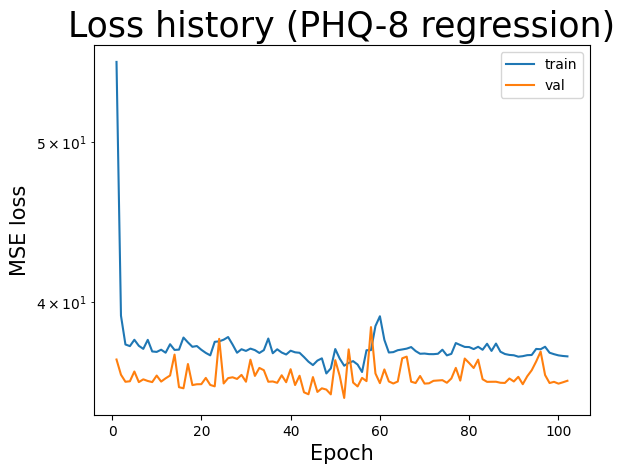

In [399]:
plt.plot(range(1, len(history["loss"]) + 1), history["loss"], label="train")
plt.plot(range(1, len(history["val_loss"]) + 1), history["val_loss"], label="val")
plt.yscale("log")
plt.title("Loss history (PHQ-8 regression)", fontsize=fontsize_title)
plt.xlabel("Epoch", fontsize=fontsize_axis)
plt.ylabel("MSE loss", fontsize=fontsize_axis)
plt.legend()
plt.show()



In [400]:
rmse_key = "output_root_mean_squared_error"
val_rmse_key = "val_output_root_mean_squared_error"
if rmse_key in history:
    plt.plot(range(1, len(history[rmse_key]) + 1), history[rmse_key], label="train")
    plt.plot(range(1, len(history[val_rmse_key]) + 1), history[val_rmse_key], label="val")
    plt.yscale("log")
    plt.title("RMSE history (PHQ-8)", fontsize=fontsize_title)
    plt.xlabel("Epoch", fontsize=fontsize_axis)
    plt.ylabel("RMSE", fontsize=fontsize_axis)
    plt.legend()
    plt.show()



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


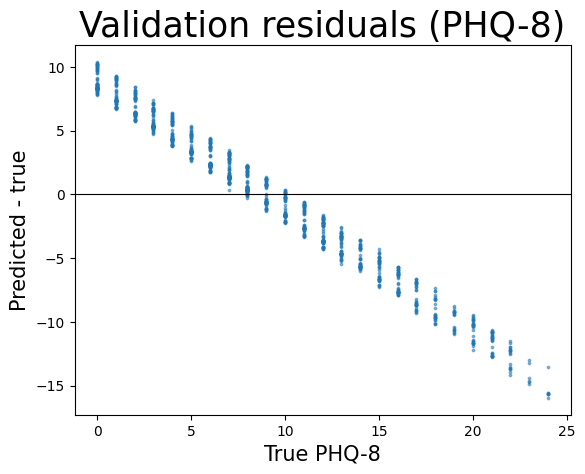

In [401]:
y_pred = ft_model.predict(val_dataset)["output"].reshape(-1)
y_true = val_data[TARGET_FEATURE].values
residual = y_pred - y_true
plt.scatter(y_true, residual, s=3, alpha=0.5)
plt.axhline(0, color="k", linewidth=0.8)
plt.title("Validation residuals (PHQ-8)", fontsize=fontsize_title)
plt.xlabel("True PHQ-8", fontsize=fontsize_axis)
plt.ylabel("Predicted - true", fontsize=fontsize_axis)
plt.show()



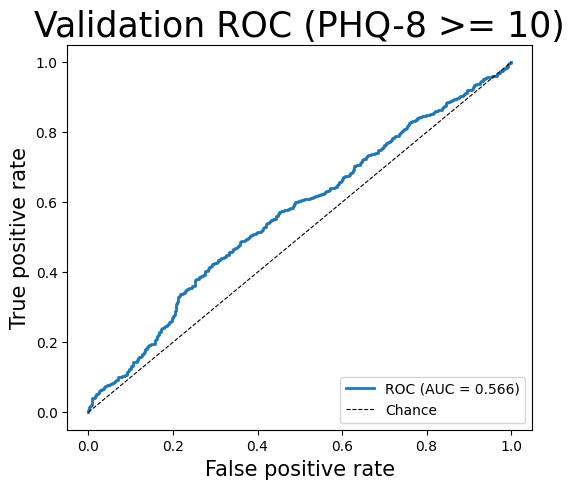

In [402]:
from sklearn.metrics import roc_curve

val_true_bin = val_data["depressed"].values
fpr, tpr, _ = roc_curve(val_true_bin, y_pred)
val_auc = roc_auc_score(val_true_bin, y_pred)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {val_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance")
plt.xlabel("False positive rate", fontsize=fontsize_axis)
plt.ylabel("True positive rate", fontsize=fontsize_axis)
plt.title(f"Validation ROC (PHQ-8 >= {PHQ8_THRESHOLD})", fontsize=fontsize_title)
plt.legend(loc="lower right")
plt.show()


# Predict

In [403]:
# Held-out participants (test_df already scaled in preprocessing cell)



In [404]:
test_dataset = radar_df_to_dataset(test_df[FEATURES], shuffle=False, batch_size=BATCH_SIZE)



In [405]:
test_pred = ft_model.predict(test_dataset)["output"].reshape(-1)
test_true = test_df[TARGET_FEATURE].values
test_pred_bin = (test_pred >= PHQ8_THRESHOLD).astype(int)
test_true_bin = test_df["depressed"].values

print("Held-out test (participant-level split)")
print(f"  MAE:  {mean_absolute_error(test_true, test_pred):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(test_true, test_pred)):.3f}")
print(f"  R2:   {r2_score(test_true, test_pred):.3f}")
print(f"  Accuracy (PHQ-8 >= {PHQ8_THRESHOLD}): {accuracy_score(test_true_bin, test_pred_bin):.3f}")
print(f"  F1:     {f1_score(test_true_bin, test_pred_bin):.3f}")
print(f"  ROC-AUC: {roc_auc_score(test_true_bin, test_pred):.3f}")



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Held-out test (participant-level split)
  MAE:  4.944
  RMSE: 5.863
  R2:   -0.022
  Accuracy (PHQ-8 >= 10): 0.627
  F1:     0.236
  ROC-AUC: 0.515


# Submit

In [406]:
print("\n=== Fairness (held-out test; same subgroup / AIF360 setup as Gradient_Boosting copy) ===\n")
test_rows_orig = df.loc[test_df.index]
fairness_sheets = collect_fairness_tables(
    MODEL_NAME, test_true_bin, test_pred_bin, test_pred, test_rows_orig
)

results_df = pd.DataFrame([
    {
        "subset": "held_out_test",
        "n_rows": len(test_df),
        "n_participants": test_df["participant_id"].nunique(),
        "mae": mean_absolute_error(test_true, test_pred),
        "rmse": np.sqrt(mean_squared_error(test_true, test_pred)),
        "r2": r2_score(test_true, test_pred),
        "accuracy": accuracy_score(test_true_bin, test_pred_bin),
        "f1": f1_score(test_true_bin, test_pred_bin),
        "roc_auc": roc_auc_score(test_true_bin, test_pred),
    }
])

test_predictions_df = test_df[["participant_id", TARGET_FEATURE, "depressed"]].copy()
test_predictions_df["phq8_pred"] = test_pred
test_predictions_df["depressed_pred"] = test_pred_bin
test_predictions_df["residual"] = test_pred - test_true

with pd.ExcelWriter(EXCEL_EXPORT_PATH, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="test_summary", index=False)
    test_predictions_df.to_excel(writer, sheet_name="test_predictions", index=False)
    for sheet_key, fdf in fairness_sheets.items():
        fdf.to_excel(writer, sheet_name=sheet_key[:31], index=False)

results_df.to_csv(RESULTS_PATH / "test_summary.csv", index=False)
test_predictions_df.to_csv(RESULTS_PATH / "test_predictions.csv", index=False)
for sheet_key, fdf in fairness_sheets.items():
    fdf.to_csv(RESULTS_PATH / f"{sheet_key}.csv", index=False)

print(f"Saved Excel results to: {EXCEL_EXPORT_PATH.resolve()}")
results_df




=== Fairness (held-out test; same subgroup / AIF360 setup as Gradient_Boosting copy) ===


RADAR FT-Transformer Gender results:
    group     n  n_depressed  n_control  accuracy        f1   roc_auc
0  female   433          119        314  0.628176  0.363636  0.606541
1    male  1512          548        964  0.626984  0.189655  0.505098

RADAR FT-Transformer Age group results:
    group    n  n_depressed  n_control  accuracy        f1   roc_auc
0  middle  527          207        320  0.629981  0.360656  0.657941
1   older  789          140        649  0.722433  0.160920  0.470102
2   young  629          320        309  0.505564  0.187990  0.525501

RADAR FT-Transformer Gender x age group results:
           group    n  n_depressed  n_control  accuracy        f1   roc_auc
0  middle female  213           90        123  0.619718  0.490566  0.716079
1    middle male  314          117        197  0.636943  0.219178  0.602629
2   older female  166            6        160  0.644578  0.063492 

,subset,n_rows,n_participants,mae,rmse,r2,accuracy,f1,roc_auc
0,held_out_test,1945,55,4.943698,5.863255,-0.022414,0.627249,0.236038,0.514959


Please give me feedbacks for improving score.

Thank you!